In [1]:
import matplotlib.pyplot as plt
import torch
from typing import List, Tuple, Sequence
from matplotlib.collections import CircleCollection
from matplotlib.patches import Circle

In [2]:
disk_radius = 16  # pixels
disk_canvas = torch.zeros(
    (disk_radius * 2, disk_radius * 2), dtype=torch.float32
)
disk_mask = torch.zeros((disk_radius * 2, disk_radius * 2), dtype=torch.float32)
pixel_grid = torch.stack(
    torch.meshgrid(
        torch.arange(disk_radius * 2 + 1),
        torch.arange(disk_radius * 2 + 1),
        indexing="ij",
    ),
    dim=-1,
)
pixel_centroids = (pixel_grid[:-1, :-1].float() + 0.5) - disk_radius

print(pixel_centroids.shape)

torch.Size([32, 32, 2])


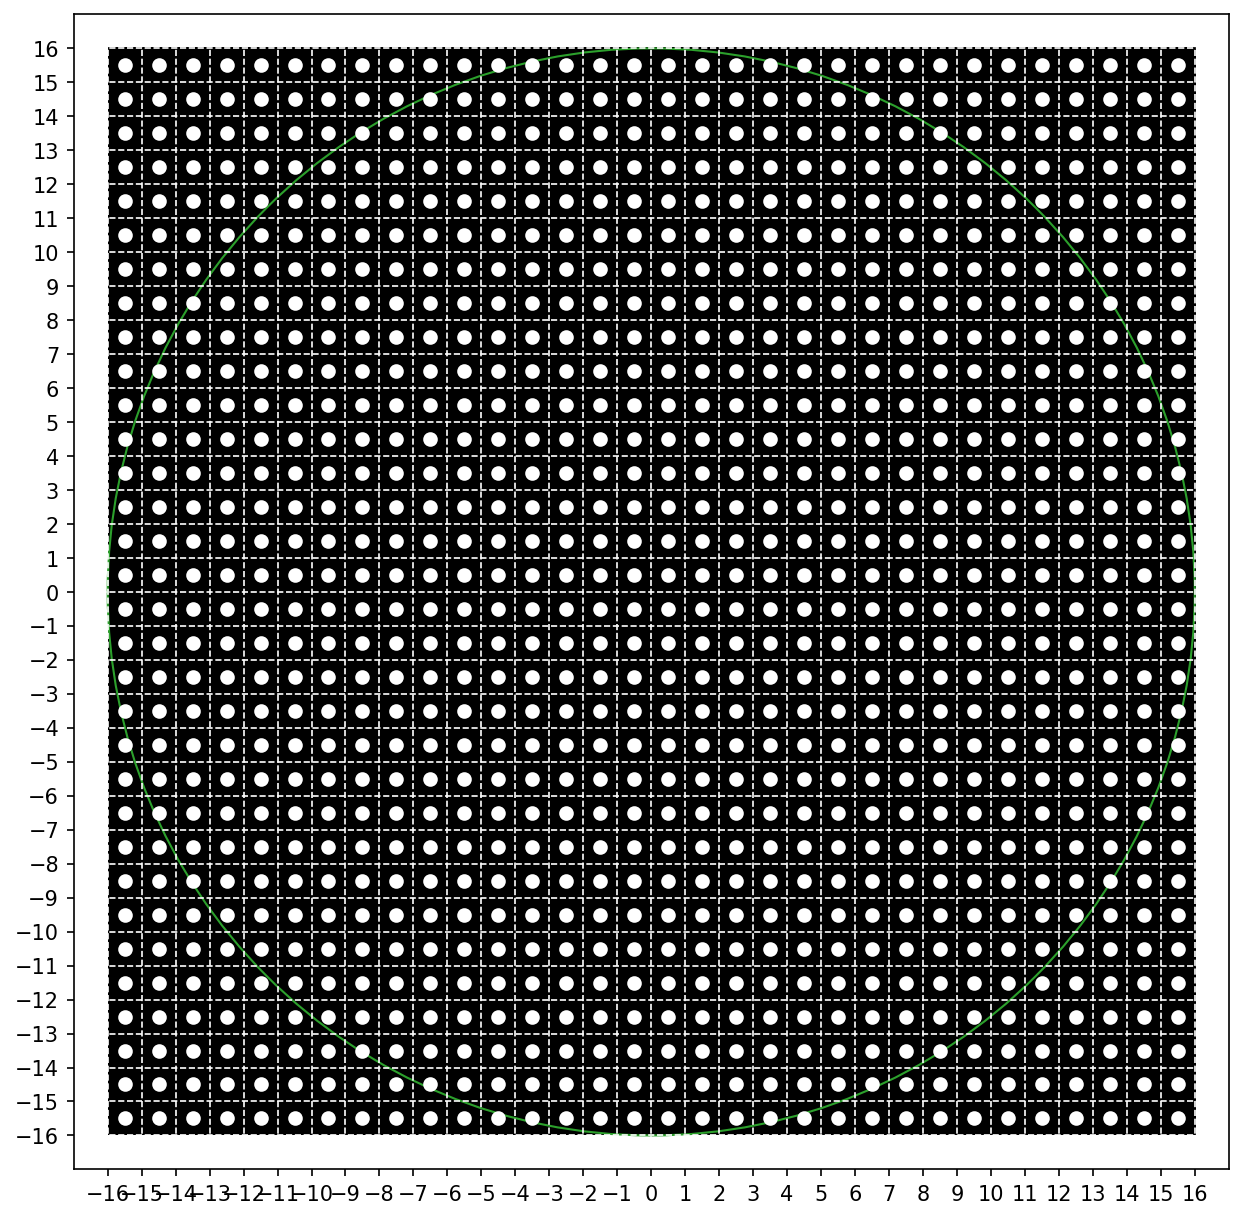

In [3]:
fig, ax = plt.subplots(dpi=150, figsize=(10, 10))
ax.imshow(
    disk_canvas.T,
    cmap="gray",
    extent=(-disk_radius, disk_radius, -disk_radius, disk_radius),
    origin="lower",
    aspect="equal",
)
ax.set_xlim(-disk_radius - 1, disk_radius + 1)
ax.set_ylim(-disk_radius - 1, disk_radius + 1)
ax.set_xticks(
    torch.arange(-disk_radius, disk_radius + 1, 1),
)
ax.set_yticks(
    torch.arange(-disk_radius, disk_radius + 1, 1),
)
ax.grid(which='both',color="white", linestyle="--")
ax.plot(
    pixel_centroids[:, :, 0],
    pixel_centroids[:, :, 1],
    "wo",
)

ax.set_aspect("equal")
perimeter = Circle((0, 0), disk_radius, fc="none", edgecolor="C2")
ax.add_patch(perimeter)

In [4]:
pixel_four_corners = torch.stack(
    (
        pixel_grid[:-1:, :-1],
        pixel_grid[1:, :-1],
        pixel_grid[1:, 1:],
        pixel_grid[:-1, 1:],
    ),
    dim=-2,
).view(-1, 4, 2)- disk_radius
print(pixel_four_corners.shape)

torch.Size([1024, 4, 2])


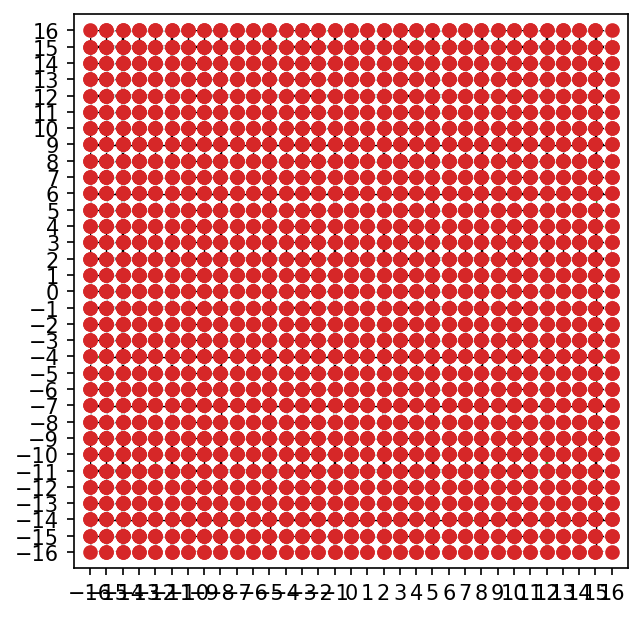

In [5]:
plt.close("all")
fig, ax = plt.subplots(dpi=150)
ax.imshow(
    disk_canvas.T,
    cmap="gray",
    extent=(-disk_radius, disk_radius, -disk_radius, disk_radius),
    origin="lower",
    aspect="equal",
)
ax.set_xticks(
    torch.arange(-disk_radius, disk_radius + 1, 1),
)
ax.set_yticks(
    torch.arange(-disk_radius, disk_radius + 1, 1),
)
ax.grid(color="white", linestyle="--")
ax.plot(
    pixel_centroids[:, :, 0],
    pixel_centroids[:, :, 1],
    "wo",
)
ax.plot(pixel_four_corners[:, :, 0].T, pixel_four_corners[:, :, 1].T, "C3o")
ax.set_xlim(-disk_radius - 1, disk_radius + 1)
ax.set_ylim(-disk_radius - 1, disk_radius + 1)
ax.set_aspect("equal")
perimeter = Circle((0, 0), disk_radius, fc="none", edgecolor="C2")
ax.add_patch(perimeter)

In [6]:
pixel_five_points = torch.cat((pixel_four_corners, pixel_centroids.view(-1, 1, 2)), dim=1)
epsilon = 1e-6
print(pixel_five_points.shape)
distance_from_center = torch.norm(pixel_five_points, dim=-1)
print(distance_from_center.shape)
inside_count = (distance_from_center <= disk_radius + epsilon).sum(dim=-1)
print(inside_count.shape)


torch.Size([1024, 5, 2])
torch.Size([1024, 5])
torch.Size([1024])


In [7]:
def high_res_disk_mask(radius_px: int) -> torch.Tensor:
    """
    Create a high-resolution disk mask.
    """
    disk_canvas = torch.zeros(
        (radius_px * 2, radius_px * 2), dtype=torch.float32
    )
    pixel_grid = torch.stack(
        torch.meshgrid(
            torch.arange(radius_px * 2 + 1),
            torch.arange(radius_px * 2 + 1),
            indexing="ij",
        ),
        dim=-1,
    )
    pixel_centroids = (pixel_grid[:-1, :-1].float() + 0.5) - radius_px
    pixel_four_corners = (
        torch.stack(
            (
                pixel_grid[:-1:, :-1],
                pixel_grid[1:, :-1],
                pixel_grid[1:, 1:],
                pixel_grid[:-1, 1:],
            ),
            dim=-2,
        ).view(-1, 4, 2)
        - disk_radius
    )
    pixel_five_points = torch.cat(
        (pixel_four_corners, pixel_centroids.view(-1, 1, 2)), dim=1
    )
    epsilon = 1e-6
    distance_from_center = torch.norm(pixel_five_points, dim=-1)
    inside_count = (distance_from_center <= disk_radius + epsilon).sum(dim=-1)
    # for count in range(5):
    #     disk_canvas.view(-1)[inside_count>count] = 0.2* count+ 0.2
    disk_canvas.view(-1)[
        distance_from_center[:, 4] < radius_px + epsilon
    ] = 1.0
    return disk_canvas


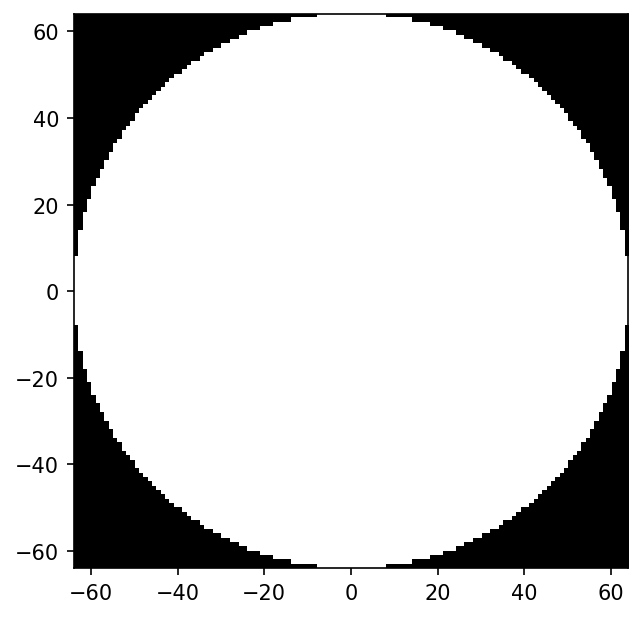

In [8]:
disk_radius = 64  # pixels
disk_high_res = high_res_disk_mask(disk_radius)
plt.close("all")
fig, ax = plt.subplots(dpi=150)
ax.imshow(
    disk_high_res.T,
    cmap="gray",
    extent=(-disk_radius, disk_radius, -disk_radius, disk_radius),
    origin="lower",
    aspect="equal",
)

In [9]:
from torch.nn import functional as F

torch.Size([256, 256])
torch.Size([16, 16])


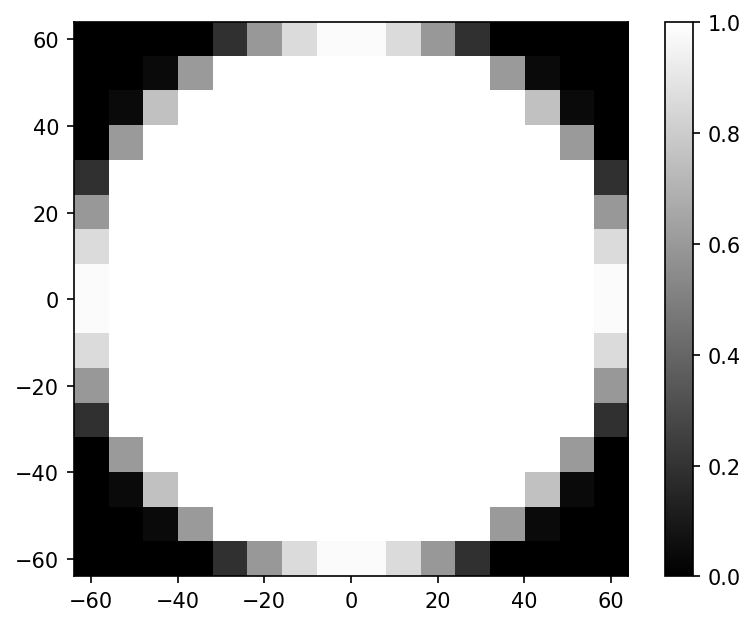

In [10]:

disk_high_res = high_res_disk_mask(128)
down_sampling_factor = 16
disk_low_res = F.conv2d(
    disk_high_res.unsqueeze(0).unsqueeze(0),
    torch.ones(
        (1, 1, down_sampling_factor, down_sampling_factor), dtype=torch.float32
    )
    / (down_sampling_factor**2),
    padding=0,
    stride=down_sampling_factor,
).squeeze()

print(disk_high_res.shape)
print(disk_low_res.shape)
plt.close("all")
fig, ax = plt.subplots(dpi=150)

fig.colorbar(
    ax.imshow(
        disk_low_res.T,
        cmap="gray",
        extent=(-disk_radius, disk_radius, -disk_radius, disk_radius),
        origin="lower",
        aspect="equal",
    )
)

torch.Size([512, 512])
torch.Size([8, 8])


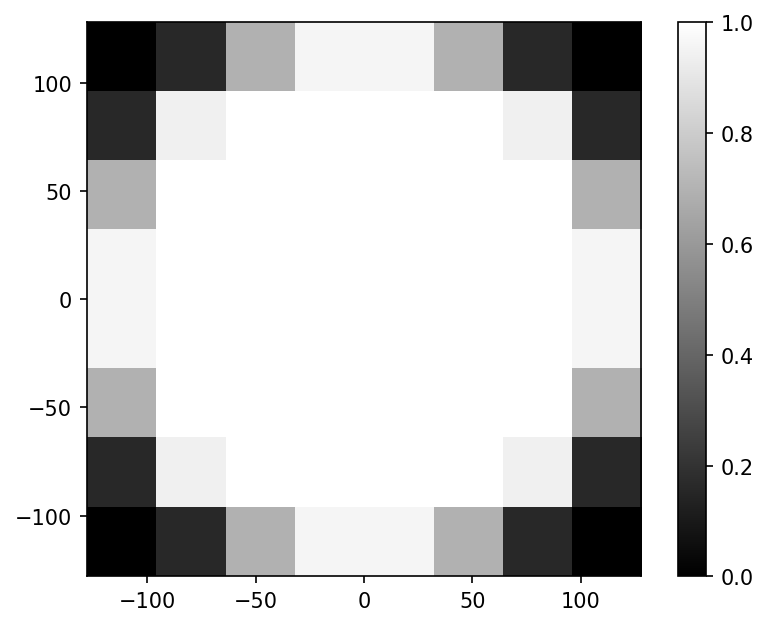

In [11]:
from _disk_shape import high_res_disk_mask, down_sample_disk_mask


radius = 128
disk_high_res = high_res_disk_mask(radius*2)
down_sampling_factor = 64
disk_low_res = down_sample_disk_mask(disk_high_res, down_sampling_factor)

print(disk_high_res.shape)
print(disk_low_res.shape)
plt.close("all")
fig, ax = plt.subplots(dpi=150)

fig.colorbar(
    ax.imshow(
        disk_low_res.T,
        cmap="gray",
        extent=(-radius, radius, -radius, radius),
        origin="lower",
        aspect="equal",
    )
)

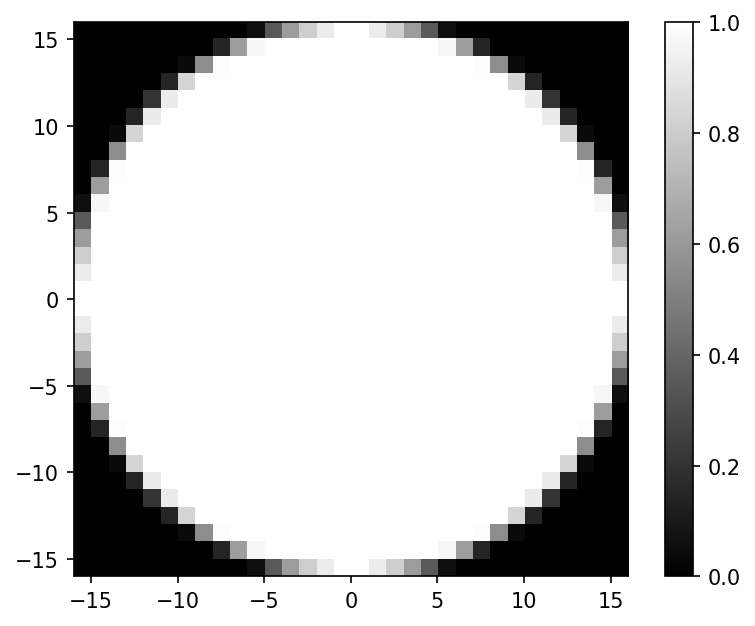

In [20]:
from _disk_shape import single_disk

radius = 16
disk = single_disk(radius,16)
plt.close("all")
fig, ax = plt.subplots(dpi=150)

fig.colorbar(
    ax.imshow(
        disk.T,
        cmap="gray",
        extent=(-radius, radius, -radius, radius),
        origin="lower",
        aspect="equal",
    )
)